In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    mean_squared_error,
    r2_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib

In [ ]:
import warnings 
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


## Why This Dataset?

I chose the PaySim financial transactions dataset because fraud detection is a critical real world problem that costs the global economy billionsof dollars every year.
This dataset simulates mobile money transactions and contains a labeled `isFraud` column, making it ideal for supervised binary classification.

Key reasons:
- Large scale: over 6 million transactions — realistic and challenging
- Imbalanced classes: fraud is rare (0.13%), just like in real life
- Rich features: transaction types, balances before/after, amounts
- Practical value: a working fraud detector can be deployed immediately

In [ ]:
df = pd.read_csv("archive\AIML Dataset.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [ ]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [ ]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [ ]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [ ]:
df.shape

(6362620, 11)

In [ ]:
round((df["isFraud"].value_counts()[1] / df.shape[0]) * 100,2)

np.float64(0.13)

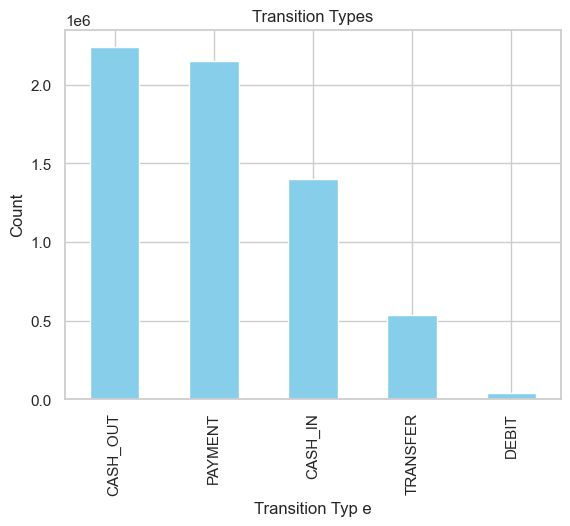

In [ ]:
df["type"].value_counts().plot(kind="bar", title="Transition Types", color = "skyblue")
plt.xlabel("Transition Typ e")
plt.ylabel("Count")
plt.show()

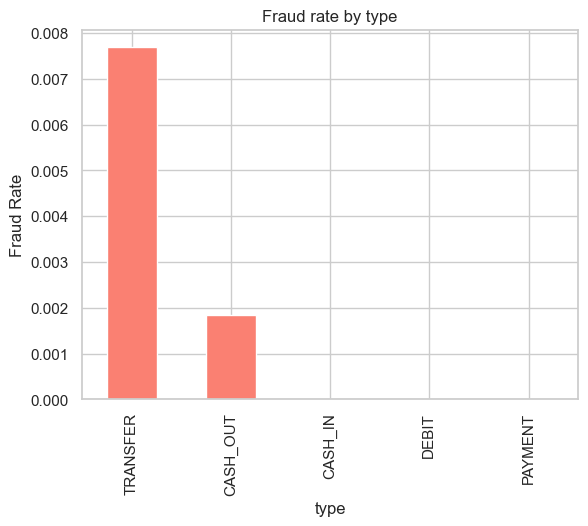

In [ ]:
Fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
Fraud_by_type.plot(kind ="bar",title = "Fraud rate by type",color="salmon")
plt.ylabel("Fraud Rate")
plt.show()

In [ ]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

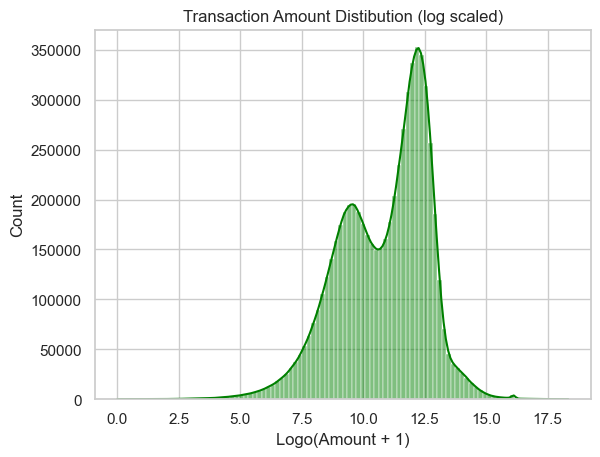

In [ ]:
sns.histplot(np.log1p(df["amount"]), bins= 100, kde = True , color = "green")
plt.title("Transaction Amount Distibution (log scaled)")
plt.xlabel("Logo(Amount + 1)")
plt.show()

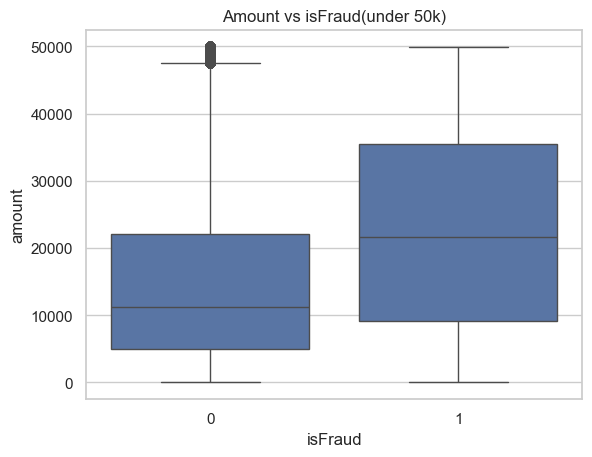

In [ ]:
sns.boxplot(data= df[df["amount"]< 50000], x ="isFraud", y ="amount")
plt.title("Amount vs isFraud(under 50k)")
plt.show()

In [ ]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [ ]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]
df["balanceDiffDest"] = df["newbalanceDest"] - df["oldbalanceDest"]

In [ ]:
(df["balanceDiffOrig"]< 0).sum()


np.int64(1399253)

In [ ]:
(df["balanceDiffDest"]< 0).sum()

np.int64(1238864)

In [ ]:

df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


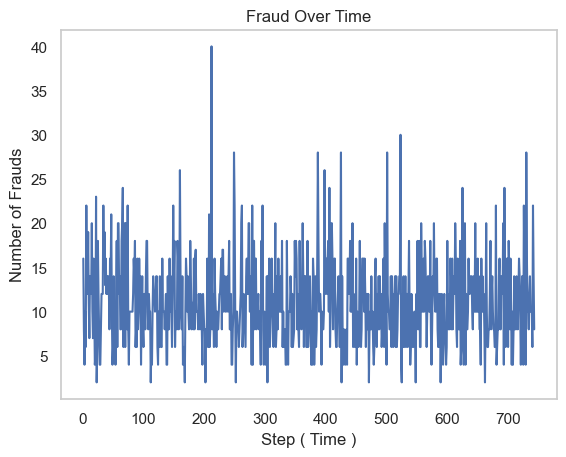

In [ ]:
frauds_per_steps = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(frauds_per_steps.index, frauds_per_steps.values, label= "Frauds per Steps")
plt.xlabel("Step ( Time )")
plt.ylabel("Number of Frauds")
plt.title("Fraud Over Time")
plt.grid(False)
plt.show()


In [ ]:
df.drop(columns="step", inplace= True)

In [ ]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [ ]:
top_senders = df["nameOrig"].value_counts().head(10)

In [ ]:
top_senders 

nameOrig
C1677795071    3
C1999539787    3
C724452879     3
C1976208114    3
C400299098     3
C1784010646    3
C1530544995    3
C1065307291    3
C545315117     3
C1902386530    3
Name: count, dtype: int64

In [ ]:
top_receivers = df["nameDest"].value_counts().head(10)


In [ ]:
top_receivers 


nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [ ]:
fraud_users = df[df["isFraud"]== 1]["nameOrig"].value_counts().head(10)

In [ ]:
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [ ]:
fraud_types = df[df["type"].isin(["TRANSFER","CASH_OUT"])]


In [ ]:
fraud_types["type"].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

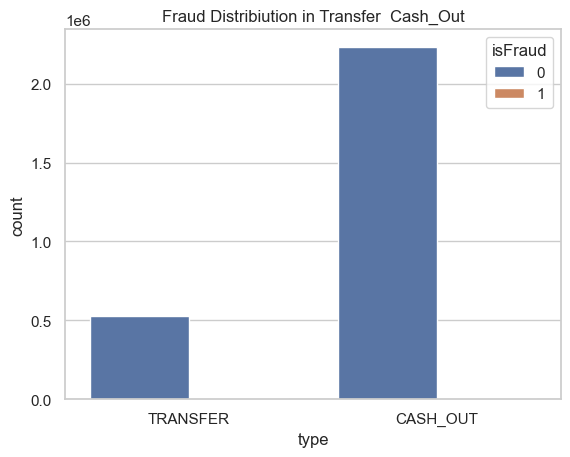

In [ ]:
sns.countplot(data = fraud_types, x = "type", hue="isFraud" )
plt.title("Fraud Distribiution in Transfer  Cash_Out")
plt.show()

In [ ]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [ ]:
corr = df[["amount", "oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest", "isFraud"]].corr()

In [ ]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


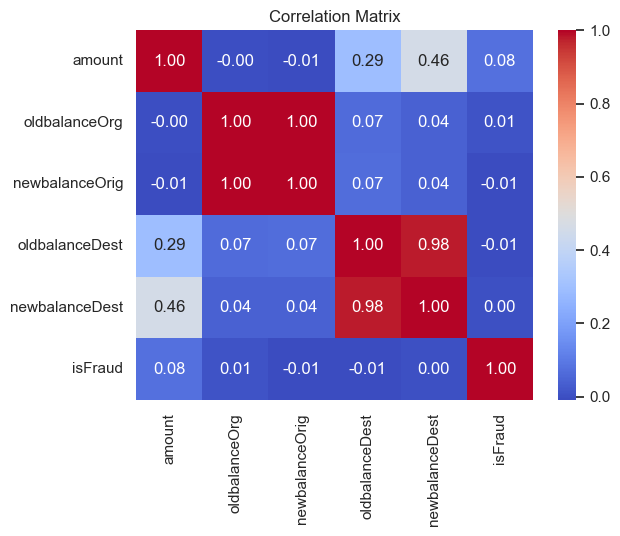

In [ ]:
sns.heatmap(corr, annot= True, cmap ="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [ ]:
zero_after_transfer = df[
    (df["oldbalanceOrg"]>0) &
    (df["newbalanceOrig"] == 0) & 
    (df["type"].isin(["TRANSFER","CASH_OUT"]))
]

In [ ]:
len(zero_after_transfer)

1188074

In [ ]:
zero_after_transfer.head()


,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


In [ ]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder

In [ ]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [ ]:
df_model = df.drop(["nameOrig","nameDest", "isFlaggedFraud"], axis = 1)

In [ ]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


In [ ]:
df.columns

Index(['type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='object')

In [ ]:
categorical = ["type"]
numeric = ["amount", "oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]

In [ ]:
y = df_model["isFraud"]
X = df_model.drop("isFraud",axis = 1)

In [ ]:
X_train, X_test, y_train , y_test = train_test_split( X, y ,test_size=0.3,stratify=y)

In [ ]:
preprocessor = ColumnTransformer(
    transformers =  [
        ("num",StandardScaler(), numeric),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ],
    remainder = "drop"
)

In [ ]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf",LogisticRegression(class_weight="balanced", max_iter=1000))
])

In [ ]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [ ]:
y_pred = pipeline.predict(X_test)

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [ ]:
confusion_matrix(y_test,y_pred)

array([[1804028,  102294],
       [    154,    2310]])

In [ ]:
pipeline.score(X_test, y_test) * 100

94.63281897499249

In [ ]:
import joblib 

joblib.dump(pipeline, "frad_detection_pipeline.pkl")

['frad_detection_pipeline.pkl']

# Comparing Different model 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df_model = df.drop(["nameOrig", "nameDest", "isFlaggedFraud"], axis=1)
categorical = ["type"]
numeric = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balanceDiffOrig",   # engineered feature
    "balanceDiffDest",   # engineered feature
]

X = df_model[categorical + numeric]
y = df_model["isFraud"]

print("Feature shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature shape: (6362620, 8)
Target distribution:
 isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # keeps fraud % the same in train & test
)

print(f"Training samples : {len(X_train):,}")
print(f"Testing  samples : {len(X_test):,}")
print(f"Fraud in test set: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")


Training samples : 5,090,096
Testing  samples : 1,272,524
Fraud in test set: 1,643 (0.13%)


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", StandardScaler(), numeric),
    ]
)



In [ ]:
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)


print("LOGISTIC REGRESSION — Classification Report")

print(classification_report(y_test, y_pred_lr, target_names=["Not Fraud", "Fraud"]))

LOGISTIC REGRESSION — Classification Report
              precision    recall  f1-score   support

   Not Fraud       1.00      0.95      0.97   1270881
       Fraud       0.02      0.94      0.04      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.95      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524



In [ ]:
SAMPLE_SIZE = 100_000

X_train_sample = X_train.sample(n=SAMPLE_SIZE, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1      # uses all CPU cores
    ))
])

knn_pipeline.fit(X_train_sample, y_train_sample)
y_pred_knn = knn_pipeline.predict(X_test)


print("K-NEAREST NEIGHBORS (k=5, trained on 100k sample) — Classification Report")

print(classification_report(y_test, y_pred_knn, target_names=["Not Fraud", "Fraud"]))


K-NEAREST NEIGHBORS (k=5, trained on 100k sample) — Classification Report
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00   1270881
       Fraud       0.93      0.57      0.71      1643

    accuracy                           1.00   1272524
   macro avg       0.96      0.78      0.85   1272524
weighted avg       1.00      1.00      1.00   1272524



In [ ]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=10,           # limits overfitting
        class_weight="balanced",
        random_state=42
    ))
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)



print("DECISION TREE — Classification Report")

print(classification_report(y_test, y_pred_dt, target_names=["Not Fraud", "Fraud"]))

DECISION TREE — Classification Report
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      1.00   1270881
       Fraud       0.17      0.99      0.29      1643

    accuracy                           0.99   1272524
   macro avg       0.59      0.99      0.65   1272524
weighted avg       1.00      0.99      1.00   1272524



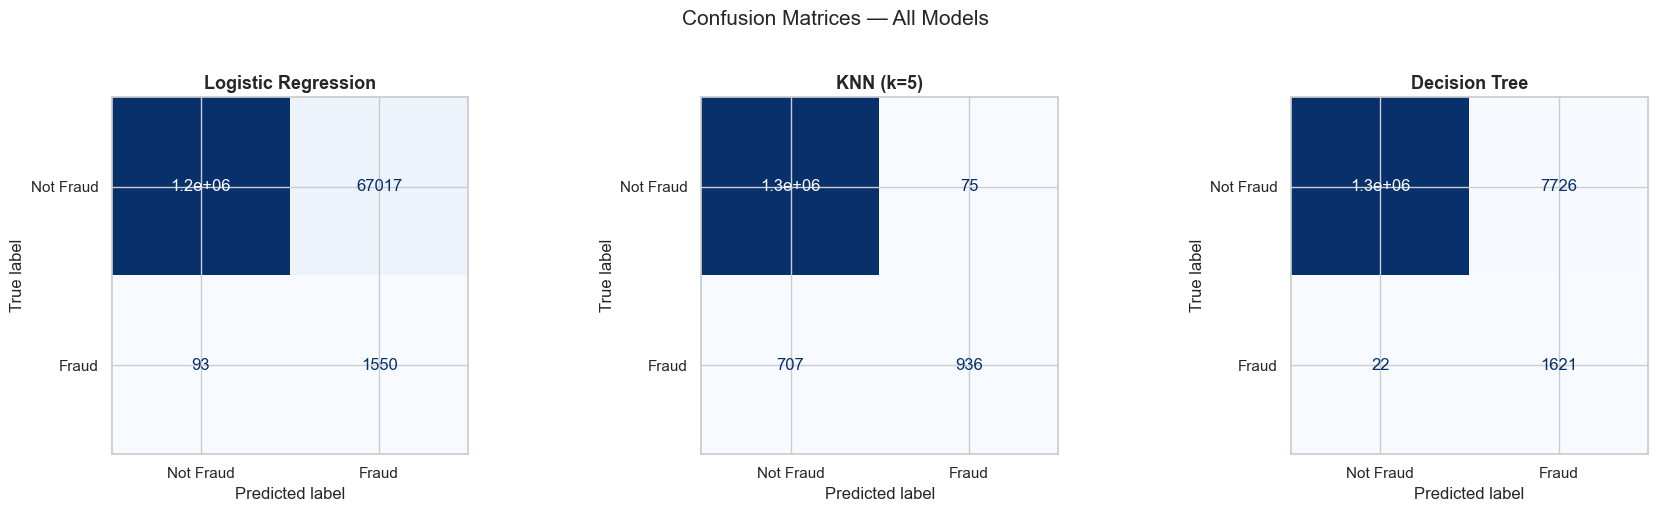

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Logistic Regression", y_pred_lr),
    ("KNN (k=5)",           y_pred_knn),
    ("Decision Tree",       y_pred_dt),
]

for ax, (name, y_pred) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Not Fraud", "Fraud"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=13, fontweight="bold")

plt.suptitle("Confusion Matrices — All Models", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
results = []
for name, y_pred in models:
    results.append({
        "Model"    : name,
        "Accuracy" : round(accuracy_score(y_test, y_pred) * 100, 2),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0) * 100, 2),
        "Recall"   : round(recall_score(y_test, y_pred, zero_division=0) * 100, 2),
        "F1-Score" : round(f1_score(y_test, y_pred, zero_division=0) * 100, 2),
    })

results_df = pd.DataFrame(results).set_index("Model")

print("MODEL COMPARISON SUMMARY")

print(results_df.to_string())

MODEL COMPARISON SUMMARY
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression     94.73       2.26   94.34      4.42
KNN (k=5)               99.94      92.58   56.97     70.54
Decision Tree           99.39      17.34   98.66     29.50


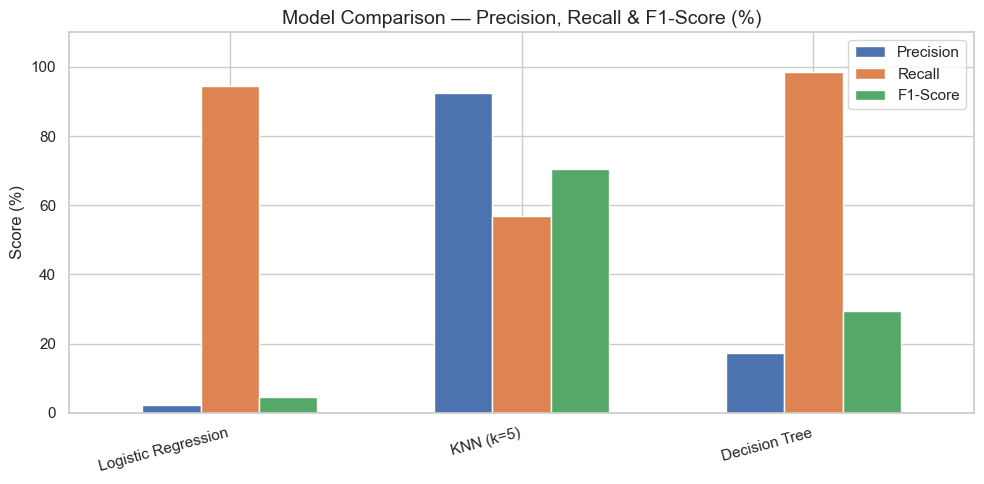

In [ ]:
ax = results_df[["Precision", "Recall", "F1-Score"]].plot(
    kind="bar",
    figsize=(10, 5),
    color=["#4C72B0", "#DD8452", "#55A868"],
    edgecolor="white",
    width=0.6
)
plt.title("Model Comparison — Precision, Recall & F1-Score (%)", fontsize=14)
plt.ylabel("Score (%)")
plt.xlabel("")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 110)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


In [ ]:
import joblib

best_model = dt_pipeline 
joblib.dump(best_model, "frad_detection_pipeline.pkl")

['frad_detection_pipeline.pkl']